[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/12_montecarlo/notebooks/02_reduccion_varianza.ipynb)

# Notebook 2: Reducción de Varianza

## El juego de reducir σ

El error del estimador Monte Carlo es:

$$\text{SE}(\hat{\mu}_n) = \frac{\sigma}{\sqrt{n}}$$

Tienes dos palancas para reducirlo:

| Palanca | Cómo | Costo |
|---------|------|-------|
| Aumentar $n$ | Tomar más muestras | Para halvar el error: 4× más muestras |
| **Reducir $\sigma$** | **Cambiar el estimador** | **Mismo $n$, menos varianza** |

Este notebook explora tres técnicas para reducir $\sigma$: **antithetic variates**, **control variates** e **importance sampling**. Al final, un dashboard comparativo.

**Prerrequisito**: haber completado el Notebook 01 (Fundamentos).

In [1]:
# Descomenta si estás en Colab
# !pip install numpy matplotlib scipy --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
print("Listo ✓")

Listo ✓


---
## Parte 1: Antithetic Variates

### La idea

Si $U \sim \text{Uniform}(0,1)$, entonces $1-U$ también es $\text{Uniform}(0,1)$ — y $U$ y $1-U$ son **negativamente correlacionados**: cuando $U$ es grande, $1-U$ es pequeño.

En lugar de estimar $\mathbb{E}[f(X)]$ con $n$ muestras independientes, usamos $n/2$ **pares** $(U_i, 1-U_i)$:

$$\hat{\mu}^{\text{AV}}_n = \frac{1}{n/2} \sum_{i=1}^{n/2} \frac{f(U_i) + f(1-U_i)}{2}$$

### ¿Por qué funciona? La matemática

La varianza del estimador antithetic es:

$$\text{Var}\left[\frac{f(U)+f(1-U)}{2}\right] = \frac{\text{Var}[f(U)] + \text{Cov}(f(U), f(1-U))}{2}$$

Si $\text{Cov}(f(U), f(1-U)) \leq 0$, entonces la varianza del estimador antithetic es **menor o igual** a la del estimador crudo.

**¿Cuándo es la covarianza negativa?** Cuando $f$ es **monótona**: si $f$ es creciente, entonces $f(U) > f(1-U)$ cuando $U > 1/2$ y $f(U) < f(1-U)$ cuando $U < 1/2$ — correlación perfectamente negativa.

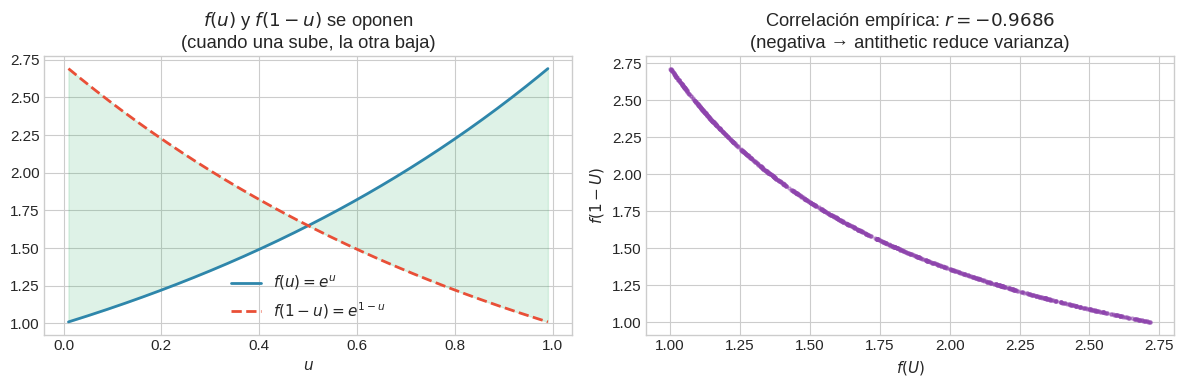

In [3]:
# Visualize the antithetic pairing
u = np.linspace(0.01, 0.99, 200)
f_exp = np.exp  # monotone increasing

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(u, f_exp(u), color="#2E86AB", lw=2, label="$f(u) = e^u$")
axes[0].plot(u, f_exp(1-u), color="#E94F37", lw=2, ls="--", label="$f(1-u) = e^{1-u}$")
axes[0].fill_between(u, f_exp(u), f_exp(1-u), alpha=0.15, color="#27AE60")
axes[0].set_title("$f(u)$ y $f(1-u)$ se oponen\n(cuando una sube, la otra baja)")
axes[0].set_xlabel("$u$")
axes[0].legend()

# Show negative correlation empirically
u_samples = np.random.default_rng(42).uniform(0, 1, 1000)
axes[1].scatter(f_exp(u_samples), f_exp(1-u_samples), s=5, alpha=0.4, color="#8E44AD")
axes[1].set_xlabel("$f(U)$")
axes[1].set_ylabel("$f(1-U)$")
corr = np.corrcoef(f_exp(u_samples), f_exp(1-u_samples))[0,1]
axes[1].set_title(f"Correlación empírica: $r = {corr:.4f}$\n(negativa → antithetic reduce varianza)")

plt.tight_layout()
plt.show()

Integral verdadera ∫₀¹ eˣ dx = 1.718282
MC crudo   — media: 1.71868, varianza: 0.000486
Antithetic — media: 1.71828, varianza: 0.000016
Reducción de varianza: 96.8%


/tmp/ipykernel_1763/4255440435.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([crude_ests, anti_ests], labels=["Crudo", "Antithetic"],


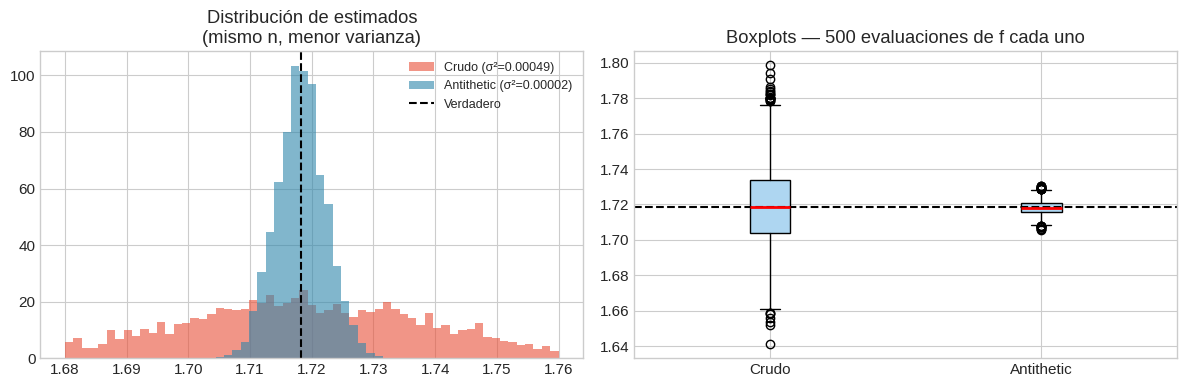

In [4]:
# Estimate integral of exp(x) over [0,1]: true value = e - 1 ≈ 1.71828
true_val = np.e - 1
f = np.exp
n = 500
n_experiments = 3000

crude_ests, anti_ests = [], []
for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    u = rng_i.uniform(0, 1, n)
    crude_ests.append(f(u).mean())

    u_half = rng_i.uniform(0, 1, n // 2)
    anti_ests.append(((f(u_half) + f(1 - u_half)) / 2).mean())

crude_var = np.var(crude_ests)
anti_var = np.var(anti_ests)

print(f"Integral verdadera ∫₀¹ eˣ dx = {true_val:.6f}")
print(f"MC crudo   — media: {np.mean(crude_ests):.5f}, varianza: {crude_var:.6f}")
print(f"Antithetic — media: {np.mean(anti_ests):.5f}, varianza: {anti_var:.6f}")
print(f"Reducción de varianza: {(1 - anti_var/crude_var)*100:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(1.68, 1.76, 60)
ax1.hist(crude_ests, bins=bins, density=True, alpha=0.6, color="#E94F37", label=f"Crudo (σ²={crude_var:.5f})")
ax1.hist(anti_ests, bins=bins, density=True, alpha=0.6, color="#2E86AB", label=f"Antithetic (σ²={anti_var:.5f})")
ax1.axvline(true_val, color="black", ls="--", lw=1.5, label="Verdadero")
ax1.set_title("Distribución de estimados\n(mismo n, menor varianza)")
ax1.legend(fontsize=9)

ax2.boxplot([crude_ests, anti_ests], labels=["Crudo", "Antithetic"],
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="red", lw=2))
ax2.axhline(true_val, color="black", ls="--", lw=1.5)
ax2.set_title(f"Boxplots — {n:,} evaluaciones de f cada uno")
plt.tight_layout()
plt.show()

### 🔧 Ejercicio: ¿Cuándo falla?

**Antithetic variates solo reduce la varianza cuando $f$ es monótona.** Construye un caso donde falle.

1. Prueba con $f(x) = \sin(4\pi x)$ — oscila 4 veces en $[0,1]$, no es monótona
2. ¿La varianza del estimador antithetic es menor, igual o mayor que la del crudo?
3. **¿Por qué?** Pista: calcula $\text{Cov}(f(U), f(1-U))$ empíricamente. ¿Es negativa?
4. ¿Puedes construir una $f$ donde la varianza *explote* con antithetic?

In [5]:
f_nonmono = lambda u: np.sin(4 * np.pi * u)  # <-- CHANGE THIS
true_nonmono = 0.0  # integral of sin(4πx) over [0,1] = 0

crude_nm, anti_nm = [], []
for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    u = rng_i.uniform(0, 1, n)
    crude_nm.append(f_nonmono(u).mean())
    u_half = rng_i.uniform(0, 1, n // 2)
    anti_nm.append(((f_nonmono(u_half) + f_nonmono(1 - u_half)) / 2).mean())

cov_emp = np.cov(
    f_nonmono(np.random.default_rng(99).uniform(0, 1, 100_000)),
    f_nonmono(1 - np.random.default_rng(99).uniform(0, 1, 100_000))
)[0, 1]

print(f"f(x) = sin(4πx)")
print(f"Cov(f(U), f(1-U)) = {cov_emp:.6f}  {'← negativa ✓' if cov_emp < 0 else '← POSITIVA → antithetic hace daño'}")
print(f"Varianza crudo:      {np.var(crude_nm):.6f}")
print(f"Varianza antithetic: {np.var(anti_nm):.6f}")
print(f"¿Antithetic mejor?  {'Sí' if np.var(anti_nm) < np.var(crude_nm) else 'No'}")

f(x) = sin(4πx)
Cov(f(U), f(1-U)) = -0.500204  ← negativa ✓
Varianza crudo:      0.001009
Varianza antithetic: 0.000000
¿Antithetic mejor?  Sí


---
## Parte 2: Control Variates

### La idea

Supón que quieres estimar $\mathbb{E}[f(X)]$ y existe una función $g(X)$ tal que:
1. $\mathbb{E}[g(X)]$ lo **conoces analíticamente**
2. $f(X)$ y $g(X)$ están **correlacionadas**

Entonces puedes construir un estimador corregido:

$$\hat{\mu}^{\text{CV}} = \frac{1}{n}\sum_i f(X_i) - c \cdot \left(\frac{1}{n}\sum_i g(X_i) - \mathbb{E}[g(X)]\right)$$

El término de corrección tiene media cero (por LLN), así que el estimador sigue siendo insesgado. Pero si elegimos $c$ bien, la varianza se reduce.

### El coeficiente óptimo

$$\text{Var}[\hat{\mu}^{\text{CV}}] = \text{Var}[f(X)] - 2c \cdot \text{Cov}(f,g) + c^2 \cdot \text{Var}[g]$$

Minimizando en $c$ (derivada igual a cero):

$$c^{∗} = \frac{\text{Cov}(f(X), g(X))}{\text{Var}[g(X)]}$$

La reducción de varianza máxima con $c^{∗}$ es:

$$\text{Var}[\hat{\mu}^{\text{CV}}_{c^{∗}}] = \text{Var}[f(X)] \cdot (1 - \rho^2_{f,g})$$

donde $\rho_{f,g} = \text{Corr}(f,g)$. Si $|\rho| = 1$: varianza cero. Si $\rho = 0$: sin mejora.

In [6]:
# Estimate integral of exp(x) over [0,1], using g(x) = x as control variate
# E[g(X)] = E[U] = 0.5 (known analytically)
# True value: e - 1 ≈ 1.71828

f_cv = np.exp
g_cv = lambda x: x
Eg = 0.5  # E[X] for X ~ Uniform(0,1)

# Estimate c* empirically (from a pilot sample)
pilot = np.random.default_rng(0).uniform(0, 1, 100_000)
cov_fg = np.cov(f_cv(pilot), g_cv(pilot))[0, 1]
var_g = np.var(g_cv(pilot))
c_star = cov_fg / var_g
rho = np.corrcoef(f_cv(pilot), g_cv(pilot))[0, 1]

print(f"Cov(f, g) = {cov_fg:.4f}")
print(f"Var(g)    = {var_g:.4f}")
print(f"c*        = {c_star:.4f}")
print(f"ρ(f,g)    = {rho:.4f}")
print(f"Reducción de varianza teórica: {(1 - rho**2)*100:.1f}% menos varianza")

Cov(f, g) = 0.1405
Var(g)    = 0.0832
c*        = 1.6890
ρ(f,g)    = 0.9918
Reducción de varianza teórica: 1.6% menos varianza


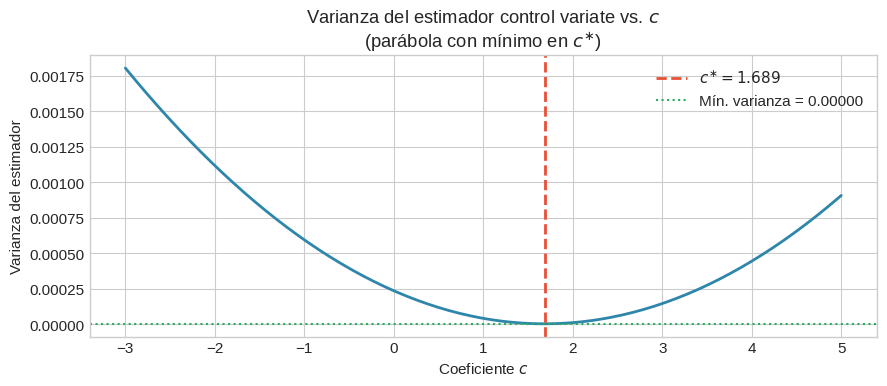

In [7]:
# Show variance as a function of c (should be parabola with min at c*)
c_values = np.linspace(-3, 5, 200)
n_pilot = 1_000
n_reps = 500

vars_by_c = []
for c in c_values:
    ests = []
    for i in range(n_reps):
        rng_i = np.random.default_rng(i)
        u = rng_i.uniform(0, 1, n_pilot)
        est = f_cv(u).mean() - c * (g_cv(u).mean() - Eg)
        ests.append(est)
    vars_by_c.append(np.var(ests))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(c_values, vars_by_c, color="#2E86AB", lw=2)
ax.axvline(c_star, color="#E94F37", ls="--", lw=2, label=f"$c^{{∗}} = {c_star:.3f}$")
ax.axhline(min(vars_by_c), color="#27AE60", ls=":", lw=1.5,
           label=f"Mín. varianza = {min(vars_by_c):.5f}")
ax.set_xlabel("Coeficiente $c$")
ax.set_ylabel("Varianza del estimador")
ax.set_title("Varianza del estimador control variate vs. $c$\n(parábola con mínimo en $c^{∗}$)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Compare crude MC vs control variate
n = 500
n_experiments = 3000
true_val = np.e - 1

crude_ests, cv_ests = [], []
for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    u = rng_i.uniform(0, 1, n)
    crude_ests.append(f_cv(u).mean())
    cv_ests.append(f_cv(u).mean() - c_star * (g_cv(u).mean() - Eg))

print(f"MC crudo         — varianza: {np.var(crude_ests):.6f}")
print(f"Control variate  — varianza: {np.var(cv_ests):.6f}")
print(f"Reducción: {(1 - np.var(cv_ests)/np.var(crude_ests))*100:.1f}%")

MC crudo         — varianza: 0.000486
Control variate  — varianza: 0.000008
Reducción: 98.4%


### 🔧 Ejercicio: Diseña tu control variate

Queremos estimar $\mathbb{E}[X^4]$ donde $X \sim \mathcal{N}(0,1)$.

El valor verdadero es $\mathbb{E}[X^4] = 3$ (cuarto momento de la normal estándar).

1. **Diseña un control variate**: ¿qué función $g(X)$ está correlacionada con $X^4$ y tiene $\mathbb{E}[g(X)]$ conocido analíticamente?
   - Pista: $\mathbb{E}[X^2] = 1$, $\mathbb{E}[X^6] = 15$, $\mathbb{E}[X^8] = 105$
   - Prueba con $g(X) = X^2$ (Var$(X^2) = \mathbb{E}[X^4] - (\mathbb{E}[X^2])^2 = 3 - 1 = 2$)

2. **Calcula $c^{∗}$** empíricamente con un piloto de 100,000 muestras

3. **Compara** la varianza del estimador crudo vs. el control variate con $n = 500$

4. **Reto**: ¿puedes mejorar aún más usando $g(X) = (X^2, X^6)$ como control variate vectorial?

In [9]:
f_normal = lambda x: x**4           # target: E[X^4] = 3
g_normal = lambda x: x**2           # <-- CHANGE THIS: try x**6, etc.
Eg_normal = 1.0                     # E[X^2] = 1 for X ~ N(0,1)
true_val_normal = 3.0

# Pilot to estimate c*
pilot_x = np.random.default_rng(0).standard_normal(200_000)
cov_normal = np.cov(f_normal(pilot_x), g_normal(pilot_x))[0, 1]
var_g_normal = np.var(g_normal(pilot_x))
c_star_normal = cov_normal / var_g_normal
rho_normal = np.corrcoef(f_normal(pilot_x), g_normal(pilot_x))[0, 1]

print(f"c* = {c_star_normal:.4f}")
print(f"ρ(f,g) = {rho_normal:.4f}")
print(f"Reducción teórica de varianza: {(1-rho_normal**2)*100:.1f}%")

n = 500
n_experiments = 3000
crude_n, cv_n = [], []
for i in range(n_experiments):
    x = np.random.default_rng(i).standard_normal(n)
    crude_n.append(f_normal(x).mean())
    cv_n.append(f_normal(x).mean() - c_star_normal * (g_normal(x).mean() - Eg_normal))

print(f"\nVarianza crudo:          {np.var(crude_n):.5f}")
print(f"Varianza control variate: {np.var(cv_n):.5f}")
print(f"Reducción empírica: {(1-np.var(cv_n)/np.var(crude_n))*100:.1f}%")

c* = 6.0591
ρ(f,g) = 0.8653
Reducción teórica de varianza: 25.1%

Varianza crudo:          0.19867
Varianza control variate: 0.04958
Reducción empírica: 75.0%


---
## Parte 3: Importance Sampling

### La idea

Hasta ahora muestreamos $X_i \sim p$. ¿Qué pasa si muestreamos de **otra distribución** $q \neq p$?

Reescribimos la integral:

$$\mu = \int f(x)\, p(x)\, dx = \int f(x) \cdot \frac{p(x)}{q(x)} \cdot q(x)\, dx = \mathbb{E}_q\left[f(X) \cdot w(X)\right]$$

donde $w(x) = p(x)/q(x)$ son los **pesos de importancia** y la esperanza es bajo $q$.

El estimador de Importance Sampling (IS) es:

$$\hat{\mu}^{\text{IS}}_n = \frac{1}{n} \sum_{i=1}^n f(X_i) \cdot w(X_i), \qquad X_i \sim q$$

**Requisito fundamental**: $q(x) > 0$ siempre que $p(x) \cdot f(x) \neq 0$.

### ¿Cuándo ayuda?

IS ayuda cuando $p$ asigna poca probabilidad a las regiones donde $f$ es grande. La idea: **muestrea donde más importa** (donde $f(x) \cdot p(x)$ es grande) y corrige el sesgo con los pesos.

### Aplicación canónica: eventos raros

Queremos estimar $P(X > 4)$ donde $X \sim \mathcal{N}(0,1)$.

El valor verdadero es $P(X > 4) \approx 3.17 \times 10^{-5}$. Muy raro.

Con MC crudo: necesitas muestrear ~30,000 puntos para esperar ver **un solo** evento. Los estimados serán casi siempre 0.

Con IS usando $q = \mathcal{N}(4, 1)$ (centrada donde queremos que ocurran los eventos): muestreamos directamente en la cola relevante.

In [10]:
from scipy.stats import norm

threshold = 4.0
true_prob = norm.sf(threshold)  # P(X > 4) for X ~ N(0,1)
print(f"P(X > {threshold}) = {true_prob:.2e}")

n = 500  # <-- CHANGE THIS
n_experiments = 1000

# Crude MC
crude_rare = []
for i in range(n_experiments):
    x = np.random.default_rng(i).standard_normal(n)
    crude_rare.append((x > threshold).mean())

# IS with q = N(4, 1)
mu_q, sigma_q = 4.0, 1.0  # <-- CHANGE THIS: try mu_q=3, mu_q=5
is_rare = []
for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    x = rng_i.normal(mu_q, sigma_q, n)  # sample from q
    # f(x) = 1(x > threshold), w(x) = p(x)/q(x)
    f_vals = (x > threshold).astype(float)
    log_w = norm.logpdf(x) - norm.logpdf(x, mu_q, sigma_q)
    w = np.exp(log_w)
    is_rare.append((f_vals * w).mean())

print(f"\nCrudo MC   — media: {np.mean(crude_rare):.2e}, var: {np.var(crude_rare):.2e}, ceros: {sum(e==0 for e in crude_rare)}/{n_experiments}")
print(f"IS (q=N(4,1)) — media: {np.mean(is_rare):.2e}, var: {np.var(is_rare):.2e}")
print(f"Verdadero: {true_prob:.2e}")
print(f"Reducción de varianza IS vs. crudo: {np.var(crude_rare)/np.var(is_rare):.0f}×")

P(X > 4.0) = 3.17e-05

Crudo MC   — media: 3.40e-05, var: 6.68e-08, ceros: 983/1000
IS (q=N(4,1)) — media: 3.18e-05, var: 9.39e-12
Verdadero: 3.17e-05
Reducción de varianza IS vs. crudo: 7117×


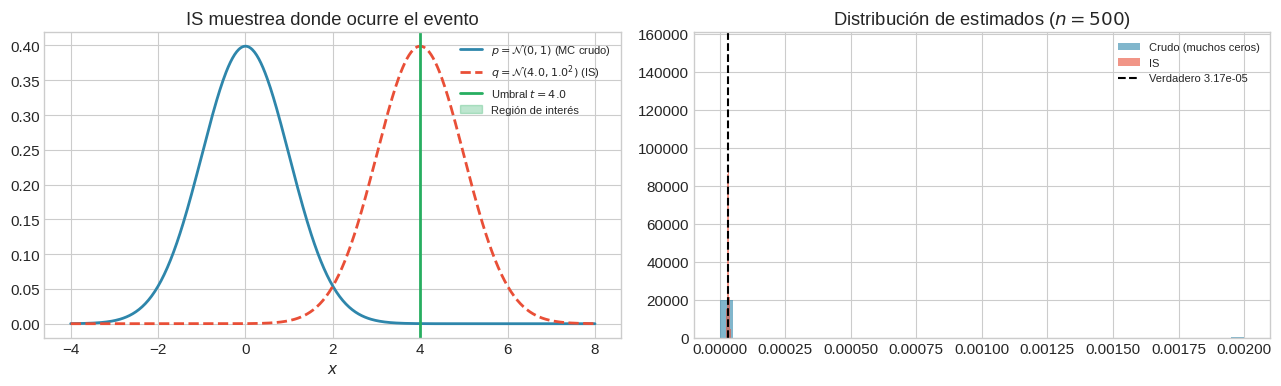

In [11]:
# Visualize: where does each method sample?
x_range = np.linspace(-4, 8, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: sampling distributions
axes[0].plot(x_range, norm.pdf(x_range), color="#2E86AB", lw=2, label="$p = \\mathcal{N}(0,1)$ (MC crudo)")
axes[0].plot(x_range, norm.pdf(x_range, mu_q, sigma_q), color="#E94F37",
             lw=2, ls="--", label=f"$q = \\mathcal{{N}}({mu_q},{sigma_q}^2)$ (IS)")
axes[0].axvline(threshold, color="#27AE60", lw=2, label=f"Umbral $t={threshold}$")
axes[0].fill_between(x_range[x_range > threshold],
                      norm.pdf(x_range[x_range > threshold]),
                      alpha=0.3, color="#27AE60", label="Región de interés")
axes[0].set_title("IS muestrea donde ocurre el evento")
axes[0].set_xlabel("$x$")
axes[0].legend(fontsize=8)

# Right: distribution of estimates
axes[1].hist(crude_rare, bins=40, density=True, alpha=0.6, color="#2E86AB", label="Crudo (muchos ceros)")
axes[1].hist(is_rare, bins=40, density=True, alpha=0.6, color="#E94F37", label="IS")
axes[1].axvline(true_prob, color="black", ls="--", lw=1.5, label=f"Verdadero {true_prob:.2e}")
axes[1].set_title(f"Distribución de estimados ($n={n}$)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 🔧 Ejercicio: El fallo catastrófico

IS puede ser **mucho peor** que MC crudo si eliges $q$ mal.

El problema: si $q$ tiene colas más **ligeras** que $p$ en las regiones donde $f$ es grande, los pesos $w(x) = p(x)/q(x)$ se vuelven enormes para ciertos $x$. Uno o dos puntos dominan todo el estimado → varianza enorme.

**Prueba esto**: estima $\mathbb{E}[X^2]$ para $X \sim \mathcal{N}(0,1)$ usando $q = \mathcal{N}(0, 0.5)$ (colas más ligeras).

1. ¿Qué pasa con los pesos $w(x)$ para $x$ grande?
2. ¿La varianza del estimador IS es mayor o menor que la del crudo?
3. **Generalización**: ¿cuándo es seguro usar IS?

σ_q = 0.5 (colas más ligeras que p=N(0,1))
Peso máximo promedio: 44.4  (¡alerta si >> 1!)
MC crudo         — varianza: 0.00406, media: 0.9969
IS (bad q)       — varianza: 0.61891, media: 0.8448
Verdadero: 1.0


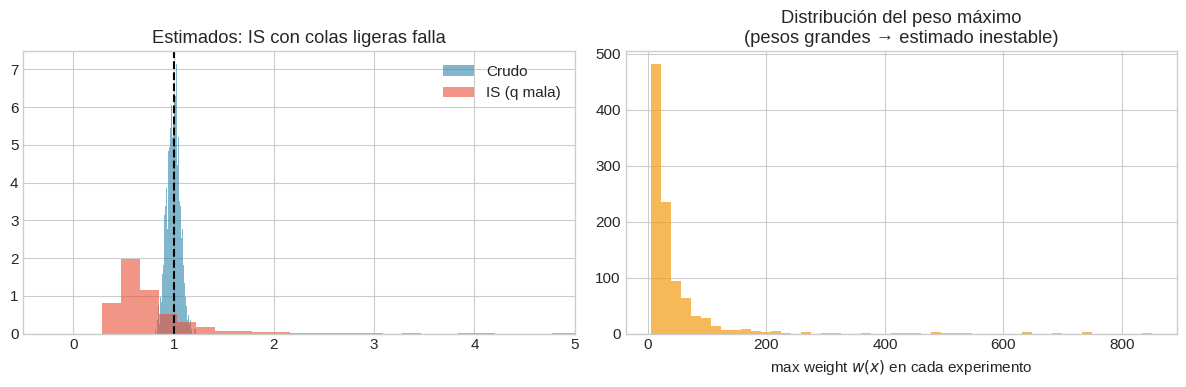

In [12]:
# Target: E[X^2] for X ~ N(0,1) = 1.0
# Bad IS: q = N(0, sigma_q) with sigma_q < 1 (lighter tails)

sigma_q_bad = 0.5  # <-- CHANGE THIS: try 0.8, 0.5, 0.3
true_val_x2 = 1.0
n = 500
n_experiments = 1000

crude_x2, is_bad_x2 = [], []
max_weights = []
for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    # Crude
    x = rng_i.standard_normal(n)
    crude_x2.append((x**2).mean())
    # Bad IS
    x_q = rng_i.normal(0, sigma_q_bad, n)
    log_w = norm.logpdf(x_q) - norm.logpdf(x_q, 0, sigma_q_bad)
    w = np.exp(log_w)
    max_weights.append(w.max())
    is_bad_x2.append((x_q**2 * w).mean())

print(f"σ_q = {sigma_q_bad} (colas más ligeras que p=N(0,1))")
print(f"Peso máximo promedio: {np.mean(max_weights):.1f}  (¡alerta si >> 1!)")
print(f"MC crudo         — varianza: {np.var(crude_x2):.5f}, media: {np.mean(crude_x2):.4f}")
print(f"IS (bad q)       — varianza: {np.var(is_bad_x2):.5f}, media: {np.mean(is_bad_x2):.4f}")
print(f"Verdadero: {true_val_x2}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(crude_x2, bins=50, density=True, alpha=0.6, color="#2E86AB", label="Crudo")
axes[0].hist(is_bad_x2, bins=50, density=True, alpha=0.6, color="#E94F37", label="IS (q mala)")
axes[0].axvline(true_val_x2, color="black", ls="--", lw=1.5)
axes[0].set_title("Estimados: IS con colas ligeras falla")
axes[0].legend()
axes[0].set_xlim(-0.5, 5)

axes[1].hist(max_weights, bins=50, color="#F39C12", alpha=0.7)
axes[1].set_title(f"Distribución del peso máximo\n(pesos grandes → estimado inestable)")
axes[1].set_xlabel("max weight $w(x)$ en cada experimento")

plt.tight_layout()
plt.show()

---
## Parte 4: Dashboard Comparativo

Comparamos los cuatro métodos en el mismo problema de referencia:

$$\mu = \int_0^1 e^x\, dx = e - 1 \approx 1.71828$$

Cada método usa exactamente **$n = 500$ evaluaciones de $f$**.

Método                 |      Media |     Varianza |   Reducción vs Crudo
------------------------------------------------------------------------
MC Crudo               |    1.71841 |     0.000483 |                0.0%
Antithetic             |    1.71828 |     0.000016 |               96.7%
Control Variate        |    1.71833 |     0.000008 |               98.4%
IS (q=Beta(2,1))       |    1.72049 |     0.005419 |            -1022.0%


/tmp/ipykernel_1763/113030501.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(list(results.values()), labels=list(results.keys()),


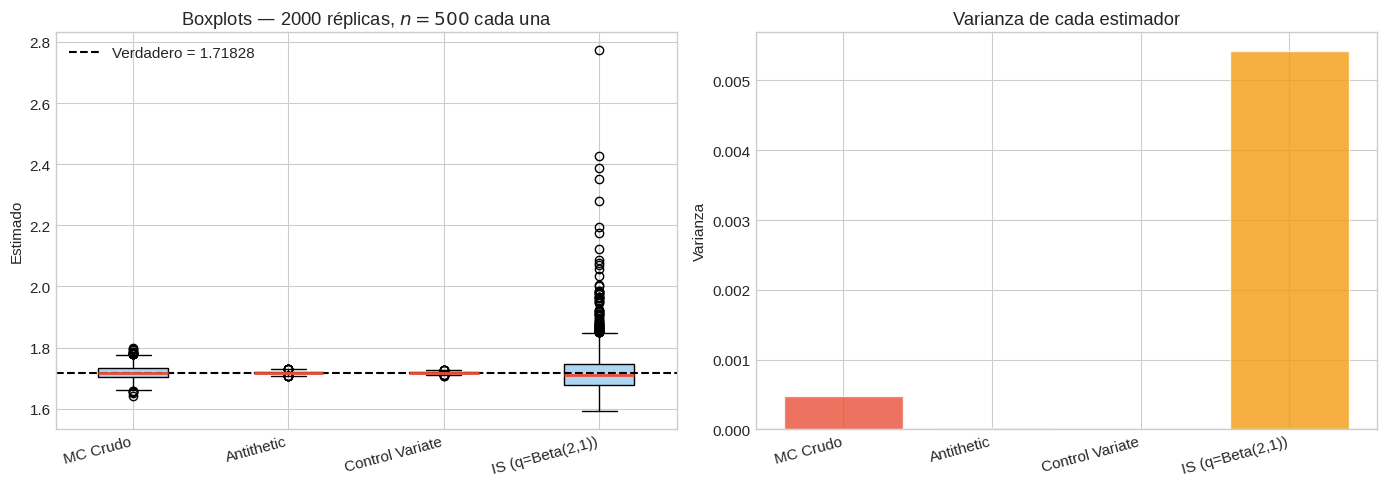

In [13]:
n = 500  # <-- CHANGE THIS to see how methods scale
n_experiments = 2000
true_val = np.e - 1
f = np.exp
g = lambda x: x
Eg_val = 0.5

# Precompute c* for control variates
pilot = np.random.default_rng(0).uniform(0, 1, 500_000)
c_opt = np.cov(f(pilot), g(pilot))[0, 1] / np.var(g(pilot))

results = {"MC Crudo": [], "Antithetic": [], "Control Variate": [], "IS (q=Beta(2,1))": []}

for i in range(n_experiments):
    rng_i = np.random.default_rng(i)
    u = rng_i.uniform(0, 1, n)

    # Crude
    results["MC Crudo"].append(f(u).mean())

    # Antithetic
    u_h = rng_i.uniform(0, 1, n // 2)
    results["Antithetic"].append(((f(u_h) + f(1 - u_h)) / 2).mean())

    # Control variate
    results["Control Variate"].append(f(u).mean() - c_opt * (g(u).mean() - Eg_val))

    # IS: q = Beta(2,1) (concentrates near 1, where exp(x) is largest)
    x_q = rng_i.beta(2, 1, n)  # Beta(2,1) pdf: q(x) = 2x
    q_pdf = 2 * x_q  # density of Beta(2,1)
    p_pdf = np.ones(n)  # density of Uniform(0,1)
    w = p_pdf / q_pdf
    results["IS (q=Beta(2,1))"].append((f(x_q) * w).mean())

print(f"{'Método':<22} | {'Media':>10} | {'Varianza':>12} | {'Reducción vs Crudo':>20}")
print("-" * 72)
var_crude = np.var(results["MC Crudo"])
for name, ests in results.items():
    v = np.var(ests)
    red = (1 - v / var_crude) * 100
    print(f"{name:<22} | {np.mean(ests):>10.5f} | {v:>12.6f} | {red:>18.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.boxplot(list(results.values()), labels=list(results.keys()),
            patch_artist=True,
            boxprops=dict(facecolor="#AED6F1"),
            medianprops=dict(color="#E94F37", lw=2))
ax1.axhline(true_val, color="black", ls="--", lw=1.5, label=f"Verdadero = {true_val:.5f}")
ax1.set_title(f"Boxplots — {n_experiments} réplicas, $n={n}$ cada una")
ax1.set_ylabel("Estimado")
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

variances = [np.var(v) for v in results.values()]
ax2.bar(list(results.keys()), variances,
        color=["#E94F37", "#2E86AB", "#27AE60", "#F39C12"], alpha=0.8, edgecolor="white")
ax2.set_title("Varianza de cada estimador")
ax2.set_ylabel("Varianza")
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

### Reflexión final: ¿cuándo usar cada método?

| Método | Cuándo usar | Supuestos | Limitación |
|--------|------------|-----------|------------|
| **Antithetic** | $f$ monotona en la variable uniforme | Solo uniforme | Falla si $f$ no es monótona |
| **Control Variate** | Tienes una función $g$ correlacionada con valor esperado conocido | Necesitas $\mathbb{E}[g]$ analítico | Requiere conocimiento del dominio |
| **Importance Sampling** | El evento de interés es raro o $p \cdot f$ tiene masa en colas de $p$ | $q > 0$ donde $p \cdot f > 0$ | Colas de $q$ deben ser ≥ colas de $p$ |

**La regla práctica**: si tienes conocimiento sobre la estructura del problema, control variates e IS pueden dar reducciones dramáticas. Si no, antithetic es la opción segura para funciones monótonas.

---

**¿Qué sigue?** Elige uno de los notebooks de aplicación:
- [03 — Opciones Financieras](aplicaciones/03_opcion_financiera.ipynb)
- [04 — Inferencia Bayesiana](aplicaciones/04_inferencia_bayesiana.ipynb)  
- [05 — Caminata Aleatoria](aplicaciones/05_caminata_aleatoria.ipynb)